In [1]:
import pandas as pd
import matplotlib.pyplot as plt

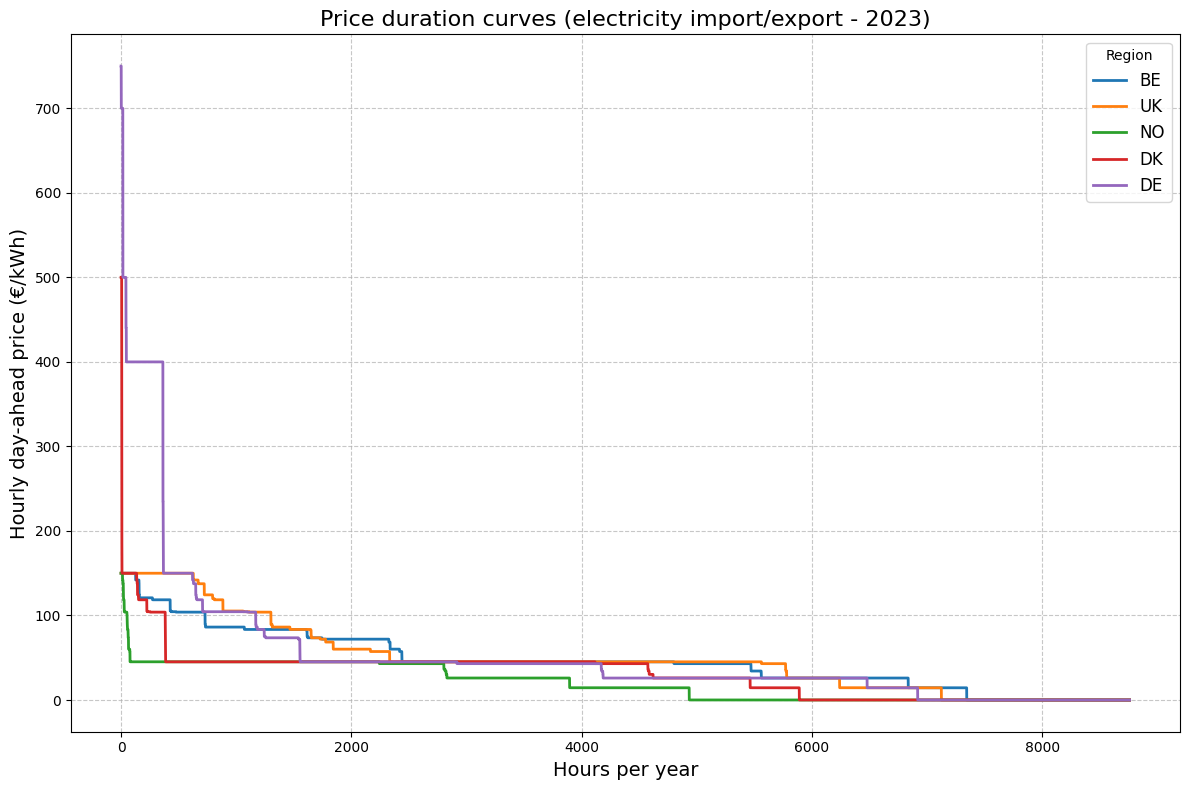

In [4]:
# File path to the CSV file
file_path = "historic_2023/price_elc_import.csv"

# Step 1: Load the CSV file
data = pd.read_csv(file_path, parse_dates=["time"])

# Step 2: Convert price columns to numeric and scale to €/kWh (assuming the input is in €/MWh)
price_columns = data.columns[1:]  # All columns except "time"
data[price_columns] = data[price_columns].apply(pd.to_numeric, errors="coerce") * 1e3  # Convert to €/kWh

# Step 3: Create a duration curve for each region
duration_curves = {}
for region in price_columns:
    # Sort prices in descending order
    sorted_prices = data[region].sort_values(ascending=False).reset_index(drop=True)
    duration_curves[region] = sorted_prices

# Step 4: Plot the price duration curves
plt.figure(figsize=(12, 8))

for region, sorted_prices in duration_curves.items():
    plt.plot(sorted_prices, label=region, linewidth=2)

# Add labels, title, and legend
plt.xlabel("Hours per year", fontsize=14)
plt.ylabel("Hourly day-ahead price (€/kWh)", fontsize=14)
plt.title("Price duration curves (electricity import/export - 2023)", fontsize=16)
plt.legend(title="Region", fontsize=12, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

# Save and show the plot
plt.tight_layout()
plt.savefig("Price_Duration_Curves_2023.pdf", dpi=300, bbox_inches="tight")
plt.show()